# Eksperimen Preprocessing - Pima Indians Diabetes Dataset
**Nama:** Indra Ajiyanto  
**Dataset:** Pima Indians Diabetes Database  
**Sumber:** https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv  
**Tujuan:** Memprediksi apakah seorang pasien menderita diabetes berdasarkan data klinis.

## 1. Perkenalan Dataset

Dataset Pima Indians Diabetes berisi data medis dari pasien wanita keturunan Pima Indian berusia minimal 21 tahun. Dataset ini terdiri dari **768 baris** dan **9 kolom**, dengan 8 fitur input dan 1 kolom target (`Outcome`).

**Fitur yang tersedia:**
| Kolom | Deskripsi |
|---|---|
| Pregnancies | Jumlah kehamilan |
| Glucose | Konsentrasi glukosa plasma |
| BloodPressure | Tekanan darah diastolik (mm Hg) |
| SkinThickness | Ketebalan lipatan kulit trisep (mm) |
| Insulin | Insulin serum 2 jam (mu U/ml) |
| BMI | Indeks massa tubuh |
| DiabetesPedigreeFunction | Fungsi silsilah diabetes |
| Age | Usia (tahun) |
| Outcome | Variabel target (1 = diabetes, 0 = tidak) |

## 2. Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

## 3. Memuat Dataset

In [22]:
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv('diabetes_raw.csv', names=columns)

print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

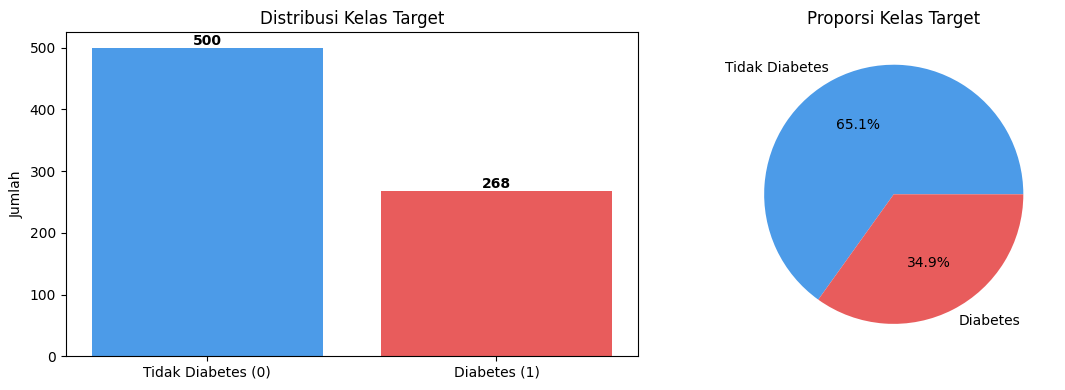

Distribusi kelas:
Outcome
0    500
1    268
Name: count, dtype: int64


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

outcome_counts = df['Outcome'].value_counts()
axes[0].bar(['Tidak Diabetes (0)', 'Diabetes (1)'], outcome_counts.values, color=['#4C9BE8', '#E85C5C'])
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(outcome_counts.values, labels=['Tidak Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=['#4C9BE8', '#E85C5C'])
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.show()
print(f'Distribusi kelas:\n{outcome_counts}')

In [26]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Jumlah nilai 0 (tidak valid) per kolom:')
for col in zero_cols:
    count = (df[col] == 0).sum()
    pct = count / len(df) * 100
    print(f'  {col:30s}: {count:3d} ({pct:.1f}%)')

Jumlah nilai 0 (tidak valid) per kolom:
  Glucose                       :   5 (0.7%)
  BloodPressure                 :  35 (4.6%)
  SkinThickness                 : 227 (29.6%)
  Insulin                       : 374 (48.7%)
  BMI                           :  11 (1.4%)


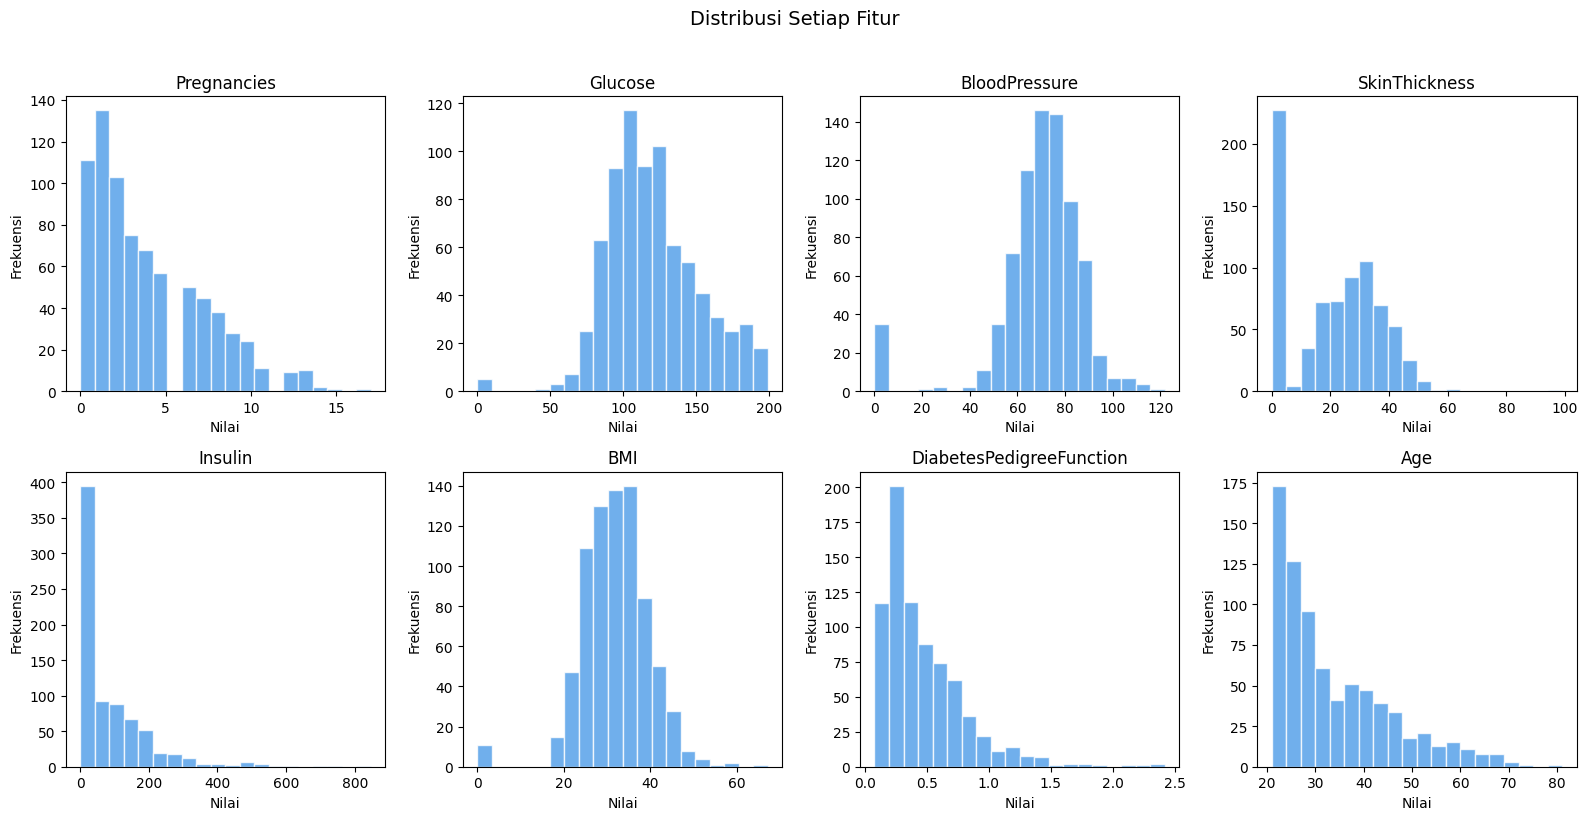

In [27]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, color='#4C9BE8', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Setiap Fitur', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

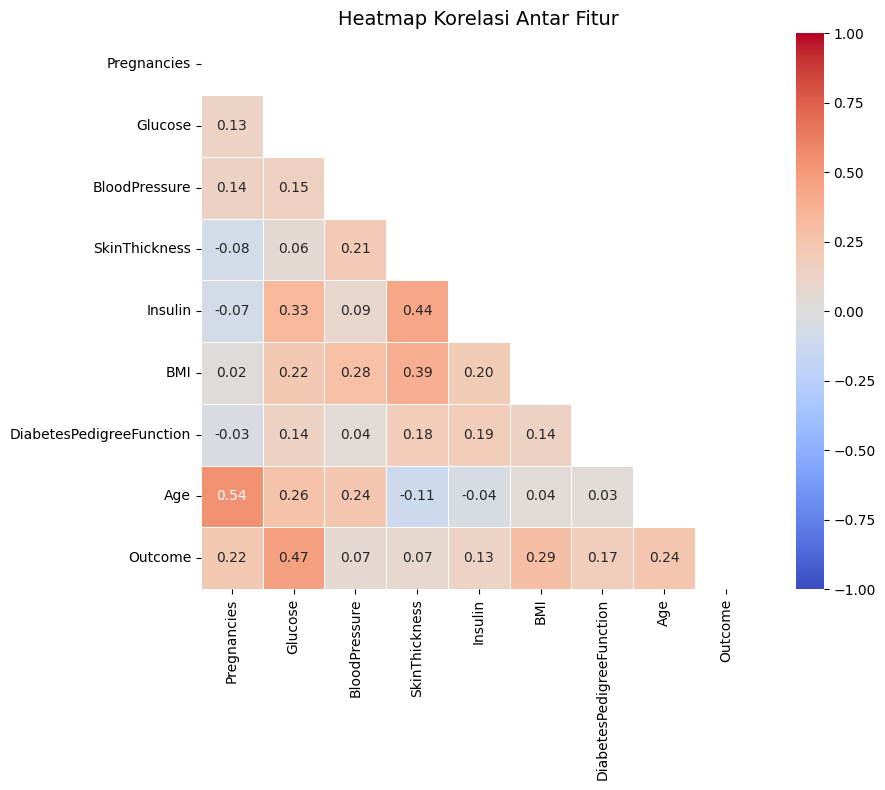

In [28]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

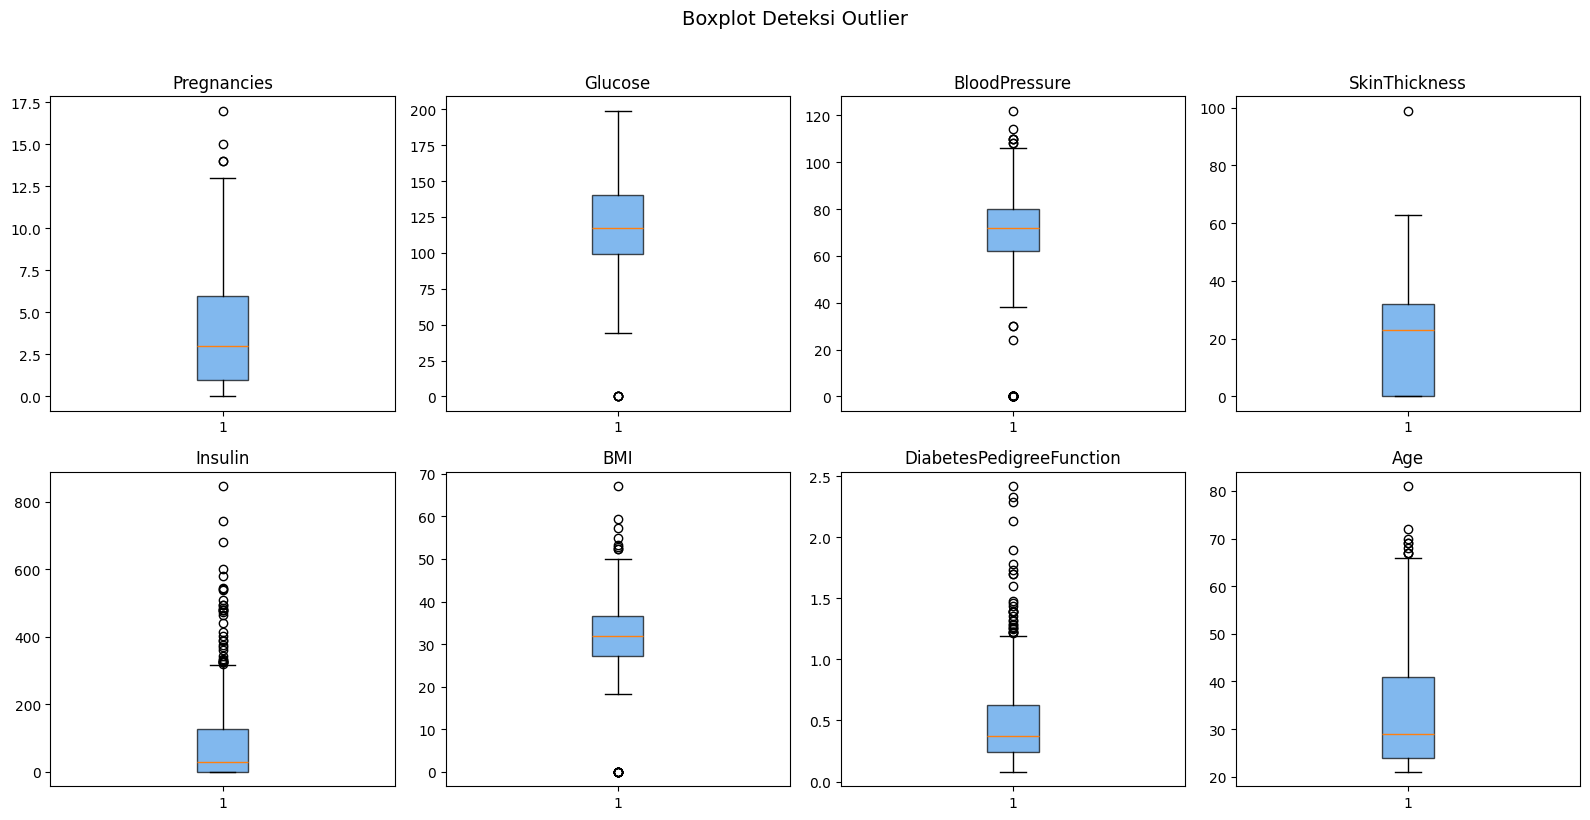

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C9BE8', alpha=0.7))
    axes[i].set_title(col)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

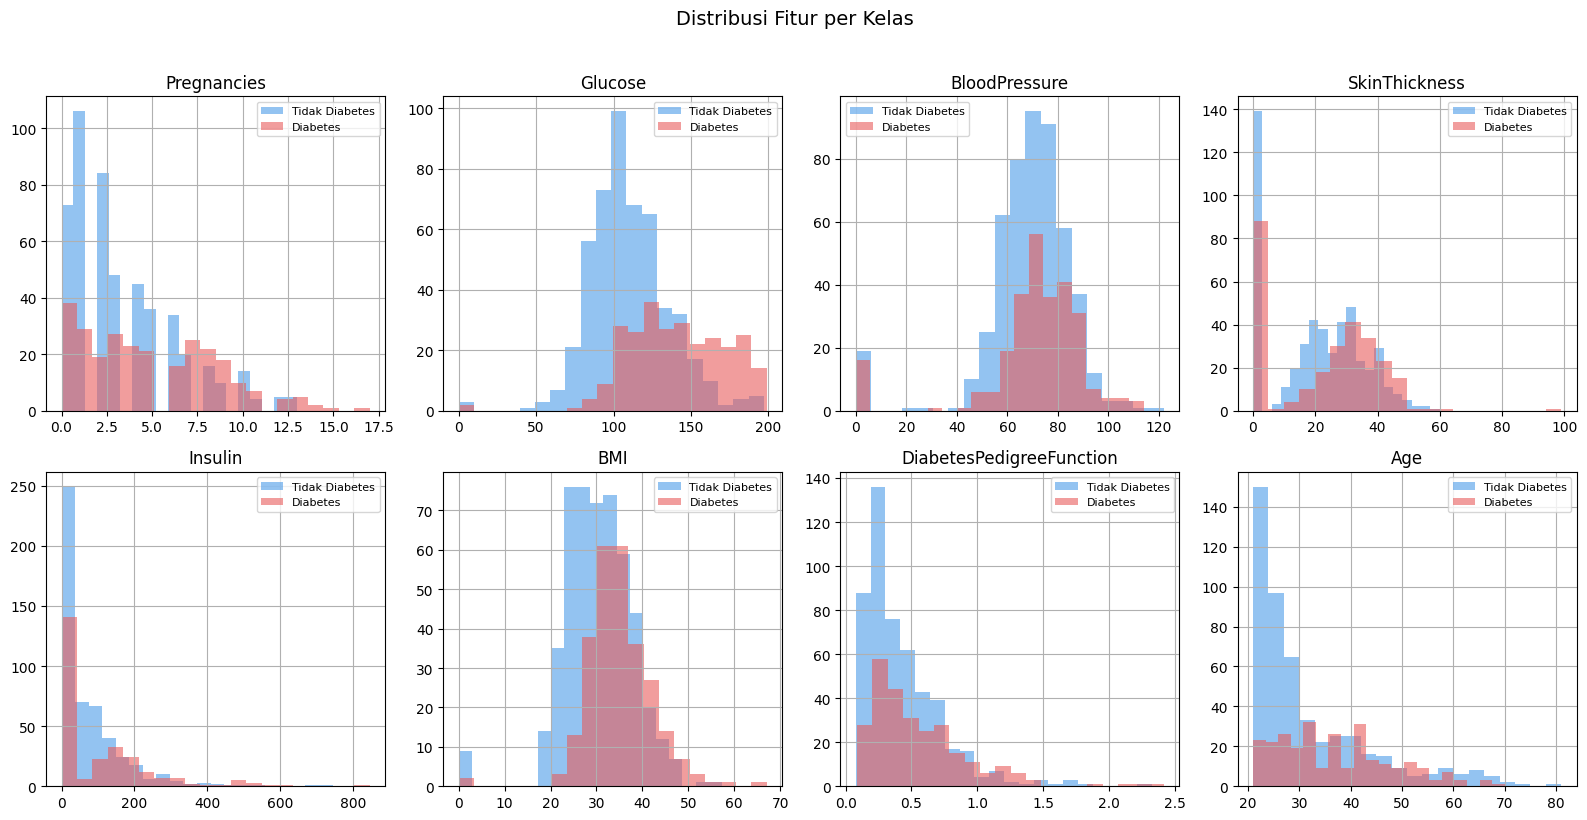

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df[df['Outcome'] == 0][col].hist(ax=axes[i], bins=20, alpha=0.6,
                                      color='#4C9BE8', label='Tidak Diabetes')
    df[df['Outcome'] == 1][col].hist(ax=axes[i], bins=20, alpha=0.6,
                                      color='#E85C5C', label='Diabetes')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur per Kelas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [31]:
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

Shape awal: (768, 9)


In [32]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print('Jumlah missing values setelah replace:')
print(df_clean[zero_cols].isnull().sum())

Jumlah missing values setelah replace:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [33]:
for col in zero_cols:
    median_0 = df_clean.loc[df_clean['Outcome'] == 0, col].median()
    median_1 = df_clean.loc[df_clean['Outcome'] == 1, col].median()
    df_clean.loc[(df_clean['Outcome'] == 0) & (df_clean[col].isnull()), col] = median_0
    df_clean.loc[(df_clean['Outcome'] == 1) & (df_clean[col].isnull()), col] = median_1

print('Missing values setelah imputasi:')
print(df_clean.isnull().sum())

Missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [34]:
dup_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
dup_after = df_clean.duplicated().sum()
print(f'Data duplikat sebelum: {dup_before}')
print(f'Data duplikat setelah: {dup_after}')
print(f'Shape setelah hapus duplikat: {df_clean.shape}')

Data duplikat sebelum: 0
Data duplikat setelah: 0
Shape setelah hapus duplikat: (768, 9)


In [35]:
outlier_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print('Jumlah outlier per kolom (metode IQR):')
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f'  {col:30s}: {outliers}')

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f'\nShape setelah handling outlier: {df_clean.shape}')

Jumlah outlier per kolom (metode IQR):
  Pregnancies                   : 4
  Glucose                       : 0
  BloodPressure                 : 14
  SkinThickness                 : 87
  Insulin                       : 51
  BMI                           : 8
  DiabetesPedigreeFunction      : 29
  Age                           : 9

Shape setelah handling outlier: (768, 9)


In [36]:
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

scaler = StandardScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

print('Statistik setelah standarisasi:')
print(df_clean[feature_cols].describe().round(3))

Statistik setelah standarisasi:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin      BMI  \
count      768.000  768.000        768.000        768.000  768.000  768.000   
mean        -0.000    0.000          0.000         -0.000    0.000   -0.000   
std          1.001    1.001          1.001          1.001    1.001    1.001   
min         -1.148   -2.551         -2.766         -1.899   -2.050   -2.125   
25%         -0.849   -0.720         -0.715         -0.509   -0.527   -0.731   
50%         -0.251   -0.154         -0.031         -0.112   -0.527   -0.048   
75%          0.647    0.610          0.653          0.417    0.627    0.634   
max          2.891    2.540          2.704          1.807    2.357    2.681   

       DiabetesPedigreeFunction      Age  
count                   768.000  768.000  
mean                     -0.000    0.000  
std                       1.001    1.001  
min                      -1.335   -1.050  
25%                      -0.754   -0.792 

In [37]:
print(f'Shape akhir: {df_clean.shape}')
df_clean.head()

Shape akhir: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.647150,0.864625,-0.030829,0.814337,0.626896,0.184034,0.588927,1.445691,1
1,-0.848970,-1.204727,-0.543685,0.020080,-0.526560,-0.865690,-0.378101,-0.189304,0
2,1.245598,2.014265,-0.714637,0.417209,0.626896,-1.360560,0.746595,-0.103252,1
3,-0.848970,-1.073339,-0.543685,-0.774176,-0.672894,-0.640749,-1.022787,-1.049828,0
4,-1.148194,0.503310,-2.766060,0.814337,0.601072,1.608659,2.596563,-0.017199,1


In [38]:
df_clean.to_csv('diabetes_preprocessing.csv', index=False)
print('Dataset hasil preprocessing berhasil disimpan ke diabetes_preprocessing.csv')

Dataset hasil preprocessing berhasil disimpan ke diabetes_preprocessing.csv
